In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import numpy as np
import os

csv_file = 'analitic_avito_dataset_50_pages.csv'

df = pd.read_csv(csv_file)

property_type_col = 'type'
space_col = 'space'
price_col = 'price'
area_price_col = 'area_price'
time_col = 'time_to_metro'
date_col = 'date'
link_col = 'link'
metro_col = 'metro'

def clean_currency_col(col):
    if col in df.columns and pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].str.replace(r'[^0-9]', '', regex=True).astype(float)

clean_currency_col(price_col)
clean_currency_col(area_price_col)

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], format='%d.%m.%Y', errors='coerce')

if price_col in df.columns:
    Q1 = df[price_col].quantile(0.25)
    Q3 = df[price_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[price_col] >= lower_bound) & (df[price_col] <= upper_bound)]

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

if time_col in df.columns:
    time_min, time_max = df[time_col].min(), df[time_col].max()
    num_bins = 5
    bins = np.linspace(time_min, time_max, num_bins + 1)
    labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    df['time_bin'] = pd.cut(df[time_col], bins=bins, labels=labels, include_lowest=True)

output_dir = 'analysis_plots'
os.makedirs(output_dir, exist_ok=True)

In [4]:
if area_price_col in df.columns and space_col in df.columns and 'time_bin' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=area_price_col, hue='time_bin', palette='viridis', data=df)
    plt.title('Цена за м² в зависимости от площади (цвет по времени до метро)')
    plt.xlabel('Площадь')
    plt.ylabel('Цена за м²')
    plt.legend(title='Время до метро (мин)')
    plt.savefig(os.path.join(output_dir, 'scatter_price_vs_space.png'))
    plt.close()

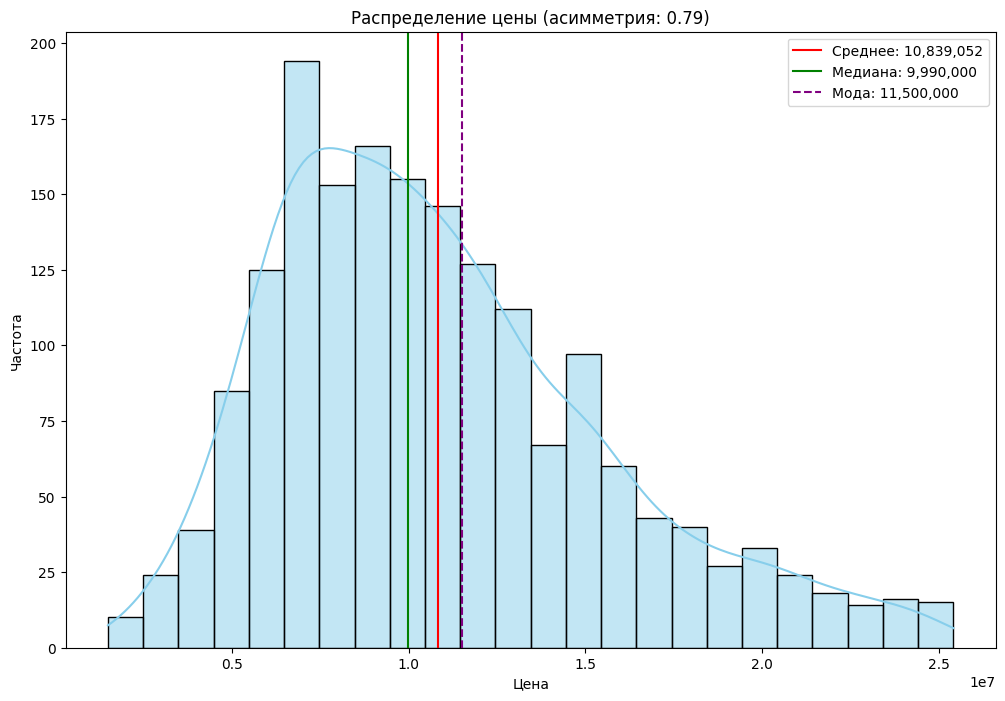

In [5]:
if price_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.histplot(df[price_col], kde=True, bins='auto', color='skyblue')
    mean_val = df[price_col].mean()
    median_val = df[price_col].median()
    mode_val = df[price_col].mode()[0] if not df[price_col].mode().empty else np.nan
    skewness_val = skew(df[price_col].dropna())

    plt.axvline(mean_val, color='red', linestyle='-', label=f'Среднее: {mean_val:,.0f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:,.0f}')
    plt.axvline(mode_val, color='purple', linestyle='--', label=f'Мода: {mode_val:,.0f}')
    plt.title(f'Распределение цены (асимметрия: {skewness_val:.2f})')
    plt.xlabel('Цена')
    plt.ylabel('Частота')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'histogram_price.png'))
    plt.show()

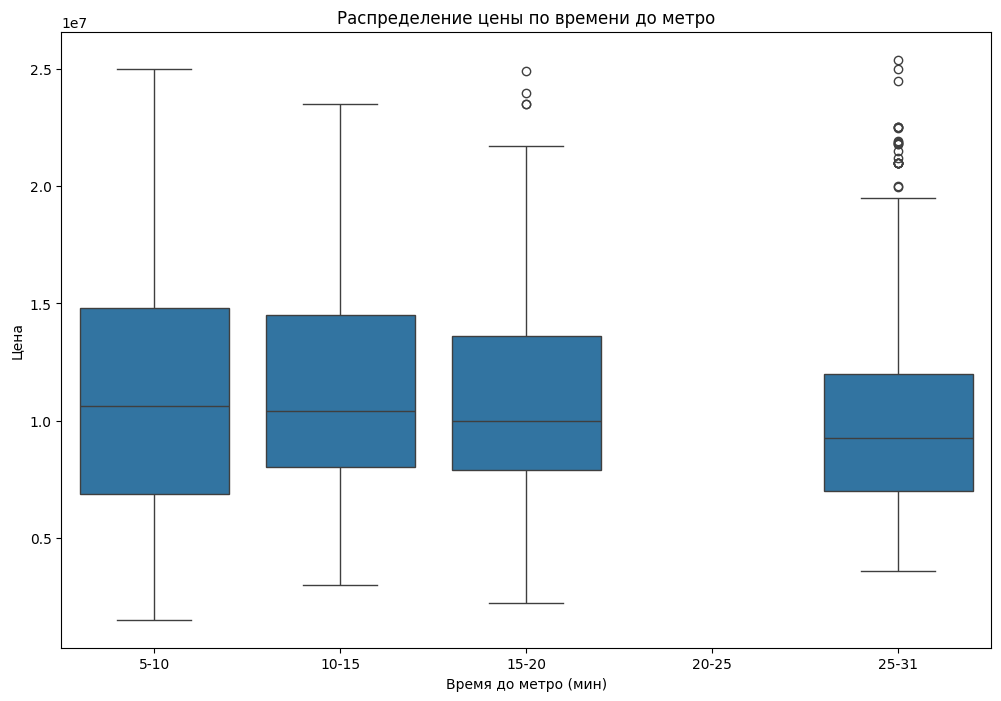

In [6]:
if price_col in df.columns and 'time_bin' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='time_bin', y=price_col, data=df)
    plt.title('Распределение цены по времени до метро')
    plt.xlabel('Время до метро (мин)')
    plt.ylabel('Цена')
    plt.savefig(os.path.join(output_dir, 'boxplot_price_by_time.png'))
    plt.show()

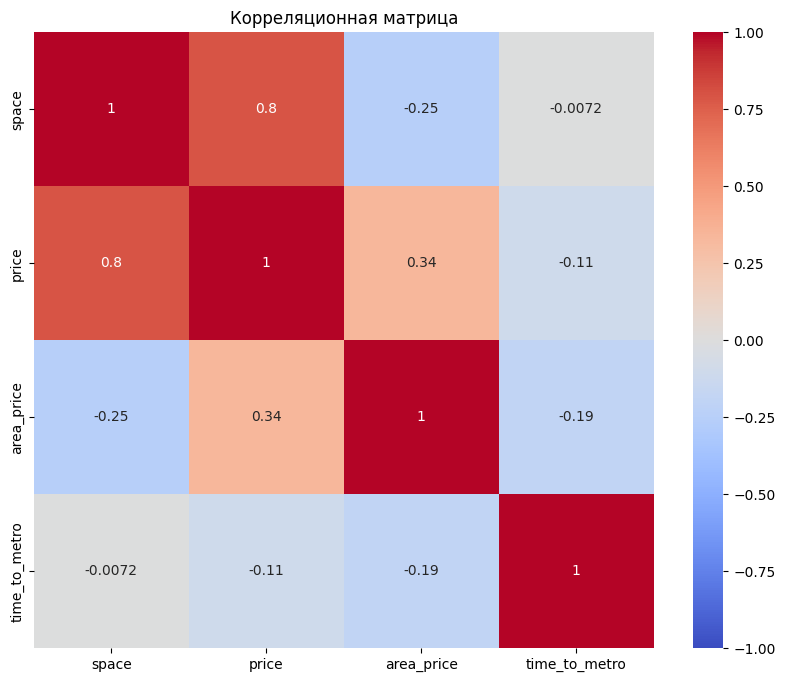

In [7]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Корреляционная матрица')
    plt.savefig(os.path.join(output_dir, 'correlation_matrix.png'))
    plt.show()

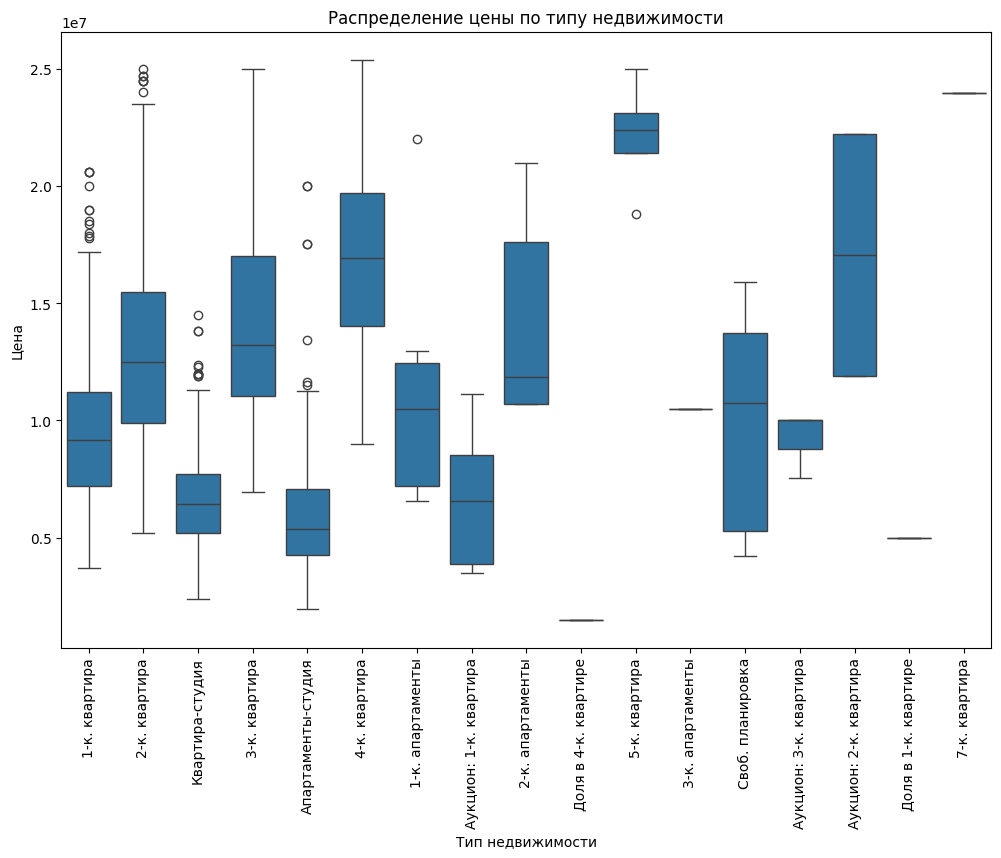

In [8]:
if price_col in df.columns and property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=property_type_col, y=price_col, data=df)
    plt.title('Распределение цены по типу недвижимости')
    plt.xlabel('Тип недвижимости')
    plt.ylabel('Цена')
    plt.xticks(rotation=90)
    plt.savefig(os.path.join(output_dir, 'boxplot_price_by_type.png'))
    plt.show()

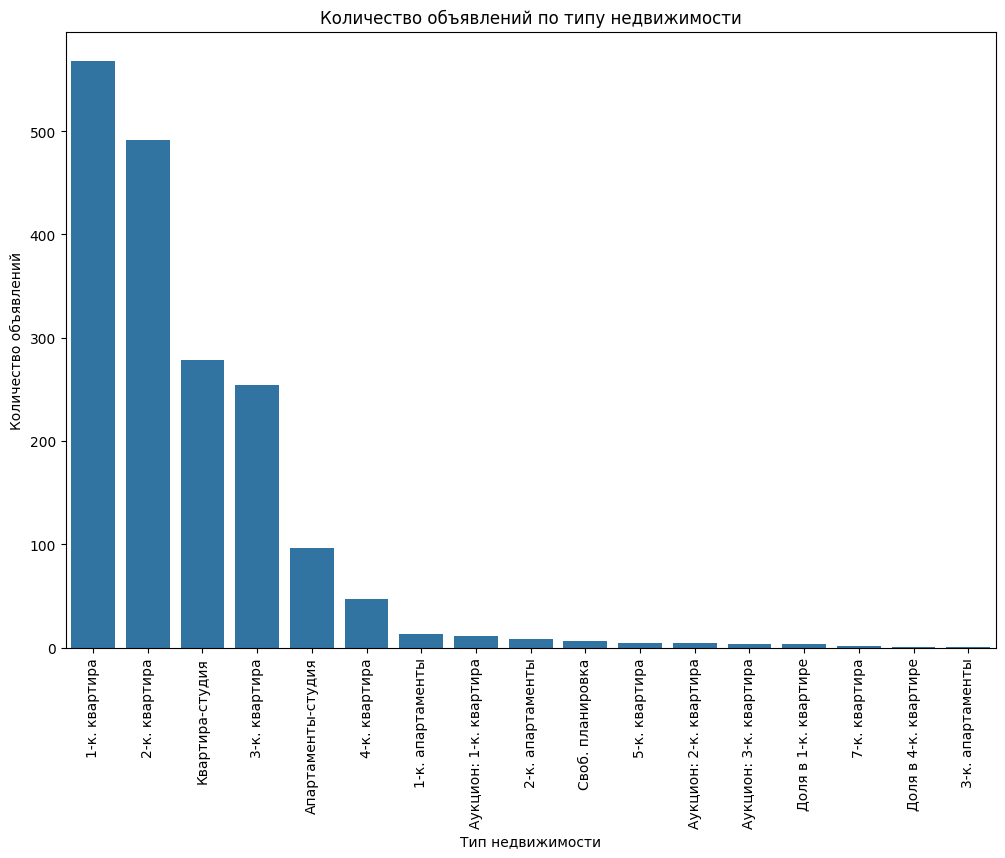

In [9]:
###NEW

if property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.countplot(x=property_type_col, data=df, order=df[property_type_col].value_counts().index)
    plt.title('Количество объявлений по типу недвижимости')
    plt.xlabel('Тип недвижимости')
    plt.ylabel('Количество объявлений')
    plt.xticks(rotation=90)
    plt.savefig(os.path.join(output_dir, 'countplot_by_type.png'))
    plt.show()

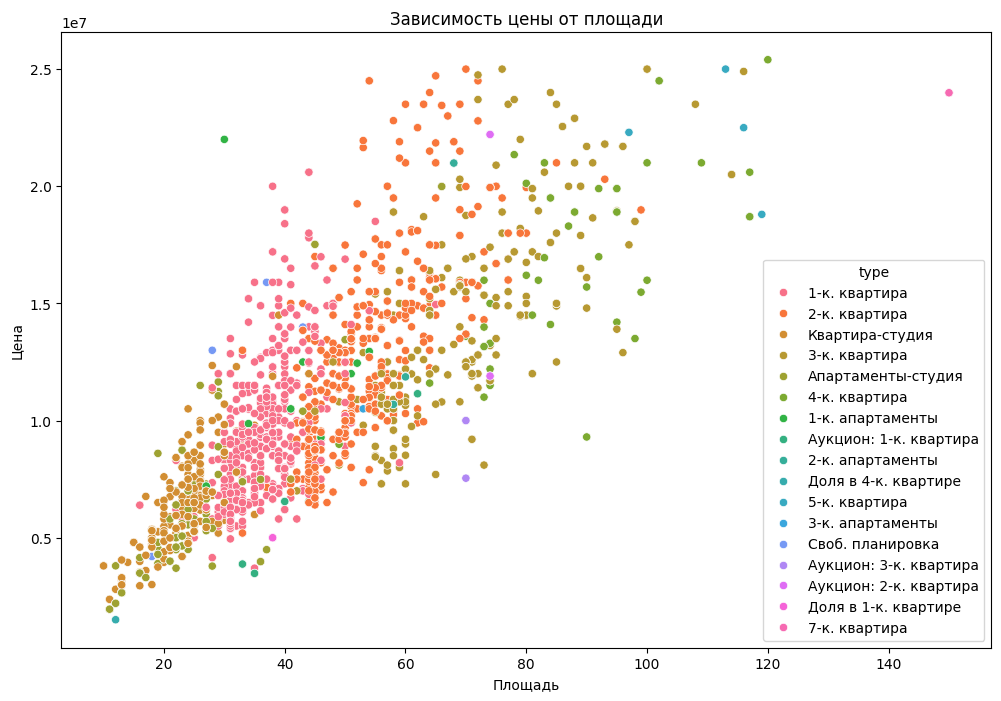

In [10]:
if space_col in df.columns and price_col in df.columns and property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=price_col,hue=property_type_col, data=df)
    plt.title('Зависимость цены от площади')
    plt.xlabel('Площадь')
    plt.ylabel('Цена')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'scatterplot_price_by_area.png'))
    plt.show()

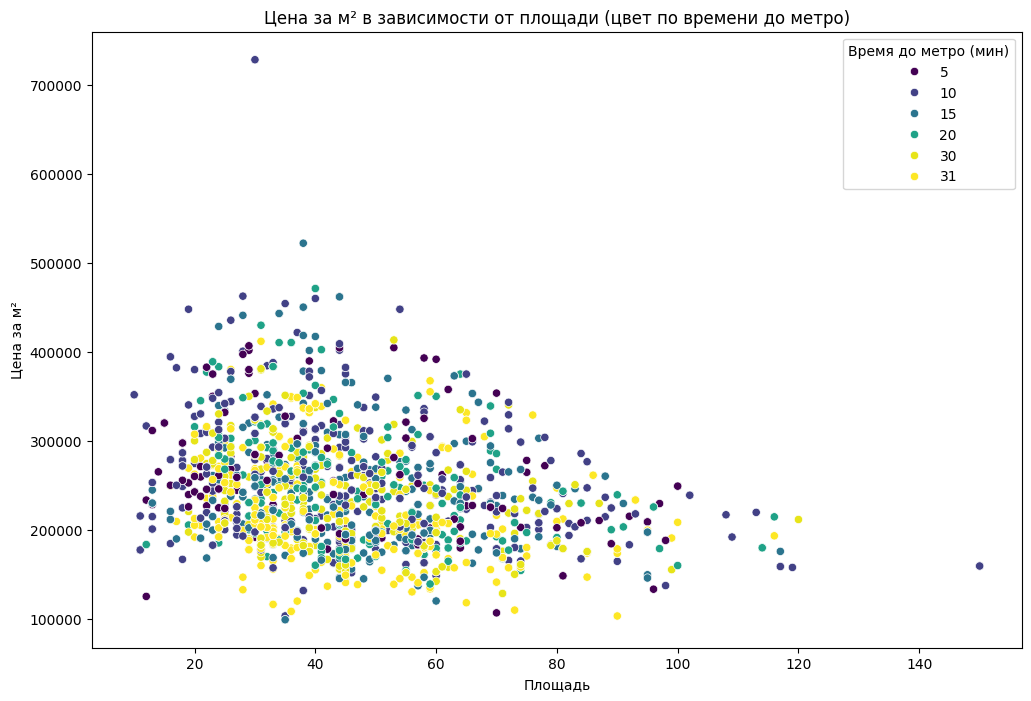

In [11]:
if area_price_col in df.columns and space_col in df.columns and time_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=area_price_col, hue=time_col, palette='viridis', data=df)
    plt.title('Цена за м² в зависимости от площади (цвет по времени до метро)')
    plt.xlabel('Площадь')
    plt.ylabel('Цена за м²')
    plt.legend(title='Время до метро (мин)')
    plt.savefig(os.path.join(output_dir, 'scatter_price_per_area_by_time.png'))
    plt.show()

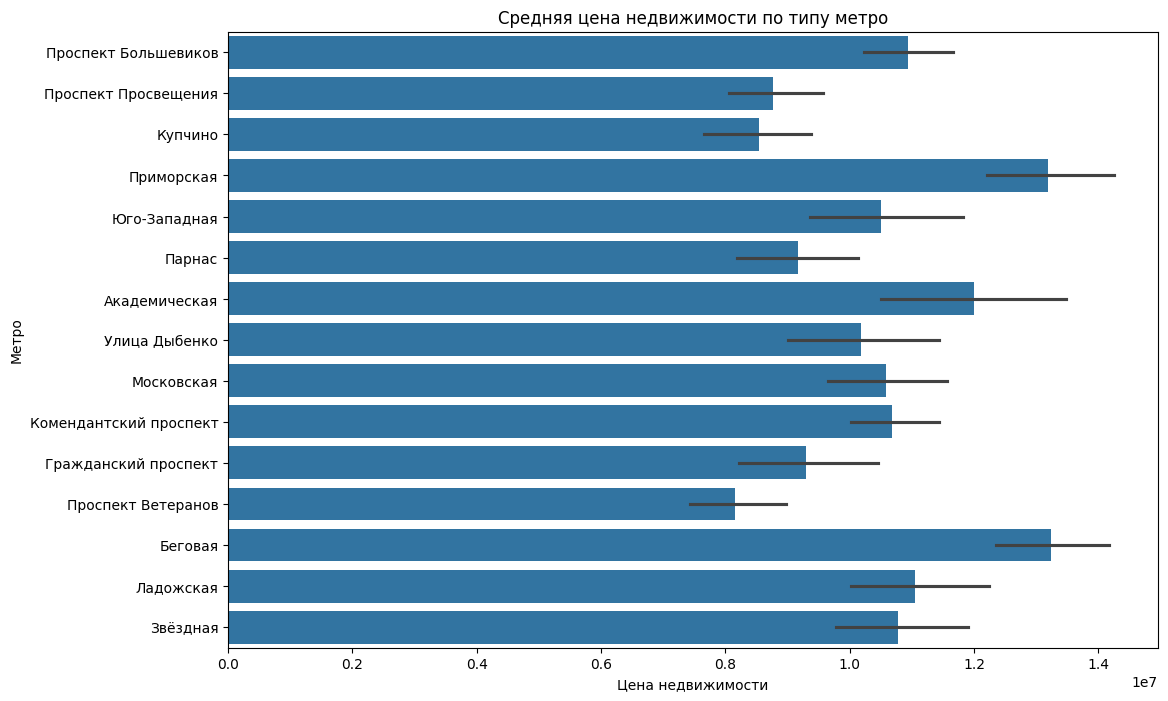

In [12]:
if metro_col in df.columns and price_col in df.columns:
    #топ 15 метро
    top_metros= df[metro_col].value_counts().head(15).index
    plt.figure(figsize=(12, 8))
    sns.barplot(x=price_col, y=metro_col, data=df[df[metro_col].isin(top_metros)], estimator=np.mean)
    plt.title('Средняя цена недвижимости по типу метро')
    plt.xlabel('Цена недвижимости')
    plt.ylabel('Метро')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'vertical_barplot.png'))
    plt.show()

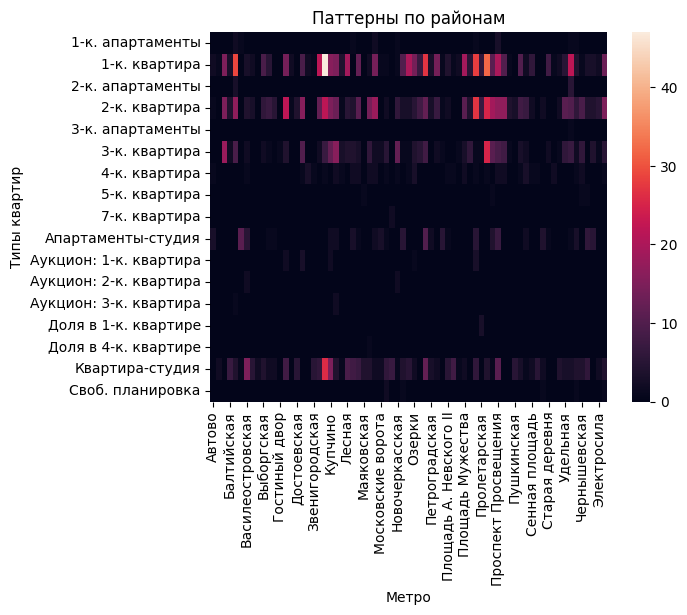

In [13]:
if metro_col in df.columns and property_type_col in df.columns:
    ct=pd.crosstab(df[property_type_col], df[metro_col])
    sns.heatmap(ct, annot=False, fmt='d')
    plt.title('Паттерны по районам')
    plt.ylabel('Типы квартир')
    plt.xlabel('Метро')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'heatmap.png'))
    plt.show()

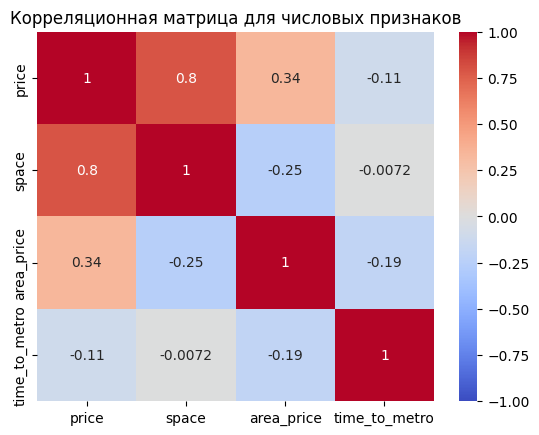

In [14]:
#Уже было

if price_col in df.columns and space_col in df.columns and area_price_col in df.columns and time_col in df.columns:
    num_cols=[price_col, space_col, area_price_col, time_col]
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Корреляционная матрица для числовых признаков')
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks()
    plt.yticks()
    plt.savefig(os.path.join(output_dir, 'correlation_matrix_numeric.png'))
    plt.show()

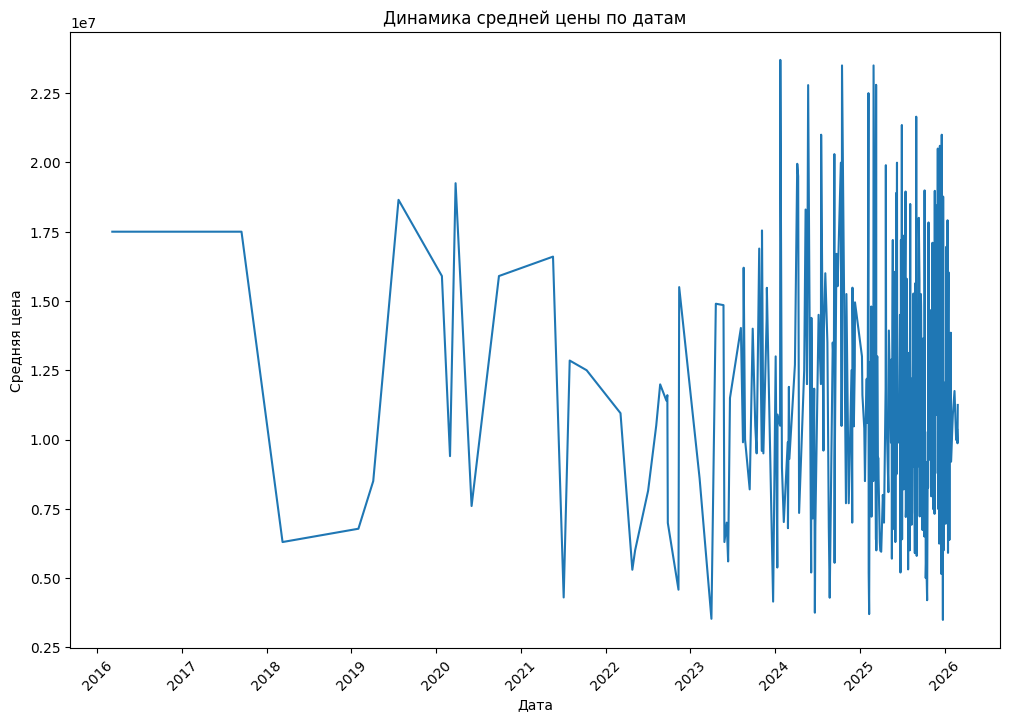

In [15]:
if date_col in df.columns and price_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col])
    df_time=df.groupby(date_col)[price_col].mean().reset_index()
    plt.figure(figsize=(12, 8))
    # df_time.set_index(date_col)[price_col].plot()
    sns.lineplot(x=date_col, y=price_col, data=df_time)
    plt.title('Динамика средней цены по датам')
    plt.xlabel('Дата')
    plt.ylabel('Средняя цена')
    plt.xticks(rotation=45)
    plt.savefig(os.path.join(output_dir, 'lineplot_price_over_time.png'))
    plt.show()

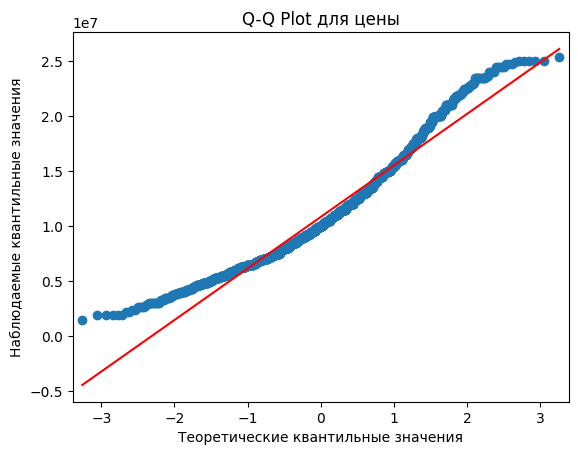

In [16]:
import statsmodels.api as sm

if price_col in df.columns:
    sm.qqplot(df[price_col], line='s')
    plt.title('Q-Q Plot для цены')
    plt.xlabel('Теоретические квантильные значения')
    plt.ylabel('Наблюдаемые квантильные значения')
    plt.xticks()
    plt.yticks()
    plt.savefig(os.path.join(output_dir, 'qqplot_price.png'))
    plt.show()


<Axes: >

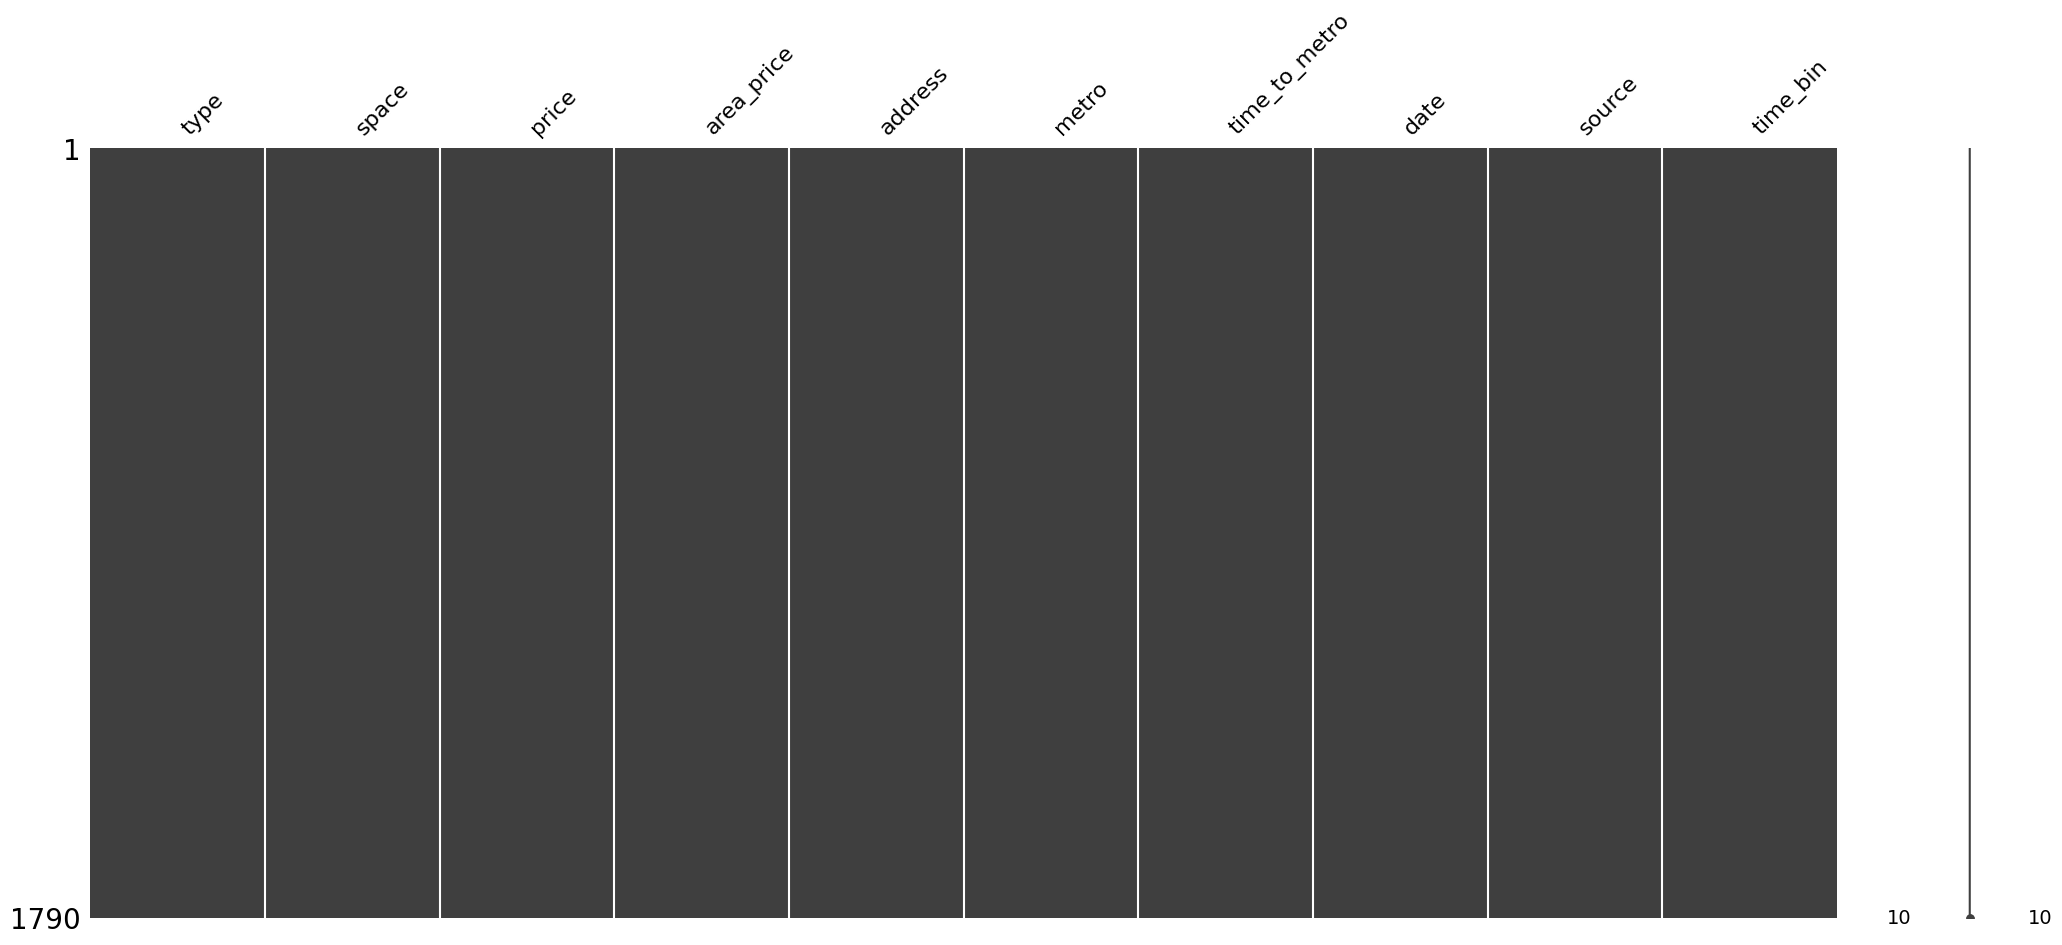

In [17]:
import missingno as msno

msno.matrix(df)



In [18]:
import plotly.express as px

if space_col in df.columns and price_col in df.columns and property_type_col in df.columns and metro_col in df.columns:
    fig=px.scatter(df, x=space_col, y=price_col, color=property_type_col, title='Зависимость цены от площади с цветом по типу недвижимости')
    fig.show(renderer='browser')

In [19]:
# num_vars = ['price', 'space', 'area_price', 'time_to_metro']
if price_col in df.columns and space_col in df.columns and area_price_col in df.columns and time_col in df.columns:
    num_vars = [price_col, space_col, area_price_col, time_col]
    stats = df[num_cols].describe().T
    stats['median'] = df[num_vars].median()
    stats['skew'] = df[num_vars].skew()
    stats['range'] = df[num_vars].max() - df[num_vars].min()
    stats['hypothesis'] = ['логнормальное / гамма', 'логнормальное', 'логнормальное', 'экспоненциальное / гамма']
    stats['reason'] = ['сильная правосторонняя асимметрия (0.79), среднее > медиана',
                    'положительная асимметрия, только >0',
                    'положительная асимметрия, только >0',
                    'время/расстояние, положительные значения']
    print(stats)

                count          mean           std        min        25%  \
price          1790.0  1.083905e+07  4.691130e+06  1500000.0  7292250.0   
space          1790.0  4.549330e+01  1.958875e+01       10.0       31.0   
area_price     1790.0  2.433355e+05  6.388073e+04    98792.0   197749.5   
time_to_metro  1790.0  1.899553e+01  9.345728e+00        5.0       10.0   

                     50%         75%         max     median      skew  \
price          9990000.0  13500000.0  25400000.0  9990000.0  0.787353   
space               42.0        57.0       150.0       42.0  0.943269   
area_price      234430.0    277286.0    728477.0   234430.0  0.999666   
time_to_metro       15.0        30.0        31.0       15.0  0.108939   

                    range                hypothesis  \
price          23900000.0     логнормальное / гамма   
space               140.0             логнормальное   
area_price       629685.0             логнормальное   
time_to_metro        26.0  экспоненциа

In [20]:
if price_col in df.columns and space_col in df.columns and area_price_col in df.columns and time_col in df.columns:
    num_vars = [price_col, space_col, area_price_col, time_col]
    table = pd.DataFrame({
    'Переменная': num_vars,
    'Среднее': df[num_vars].mean().round(2),
    'Медиана': df[num_vars].median().round(2),
    'Асимметрия': df[num_vars].skew().round(3),
    'Диапазон значений': [f"{df[v].min():,.0f} – {df[v].max():,.0f}" for v in num_vars],
    'Предполагаемое распределение': ['Логнормальное', 'Логнормальное', 'Логнормальное', 'Гамма-распределение'],
    'Обоснование': [
        'Сильная положительная асимметрия (skew=0.79), среднее > медиана, длинный правый хвост',
        'Положительная асимметрия, значения >0',
        'Сильная положительная асимметрия, значения >0, тяжёлый правый хвост',
        'Положительные значения, убывающая частота с ростом времени'
        ]
    })

print(table.to_string(index=False))

   Переменная     Среднее   Медиана  Асимметрия      Диапазон значений Предполагаемое распределение                                                                           Обоснование
        price 10839052.33 9990000.0       0.787 1,500,000 – 25,400,000                Логнормальное Сильная положительная асимметрия (skew=0.79), среднее > медиана, длинный правый хвост
        space       45.49      42.0       0.943               10 – 150                Логнормальное                                                 Положительная асимметрия, значения >0
   area_price   243335.46  234430.0       1.000       98,792 – 728,477                Логнормальное                   Сильная положительная асимметрия, значения >0, тяжёлый правый хвост
time_to_metro       19.00      15.0       0.109                 5 – 31          Гамма-распределение                            Положительные значения, убывающая частота с ростом времени


In [21]:
if property_type_col in df.columns and metro_col in df.columns:
    cat_vars =  [metro_col]
    for col in cat_vars:
        print(f'\n{col}:')
        print(df[col].value_counts())
        print('Уникальных:', df[col].nunique())


metro:
metro
Комендантский проспект    103
Проспект Большевиков       87
Приморская                 72
Проспект Просвещения       69
Парнас                     69
                         ... 
Девяткино                   3
Адмиралтейская              3
Технологический ин-т I      3
Волковская                  2
Гостиный двор               1
Name: count, Length: 71, dtype: int64
Уникальных: 71


In [22]:
if price_col in df.columns and space_col in df.columns and area_price_col in df.columns:
    for col in [price_col, space_col, area_price_col]:
        print(f"{col}: μ = {df[col].mean():.2f}, σ = {df[col].std():.2f}")

price: μ = 10839052.33, σ = 4691130.04
space: μ = 45.49, σ = 19.59
area_price: μ = 243335.46, σ = 63880.73


In [23]:
# Очистка числовых колонок

from scipy import stats

for col in [price_col, space_col, area_price_col, time_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=[price_col, space_col, area_price_col])

for col in [price_col, space_col, area_price_col]:
    sample = df_clean[col].dropna().sample(min(5000, len(df_clean)), random_state=42)
    stat, p = stats.shapiro(sample[:5000])
    print(f"{col}: stat={stat:.4f}, p={p:.4e}, {'НЕ нормальное' if p < 0.05 else 'нормальное'}")

price: stat=0.9539, p=2.4795e-23, НЕ нормальное
space: stat=0.9507, p=4.5125e-24, НЕ нормальное
area_price: stat=0.9530, p=1.5588e-23, НЕ нормальное


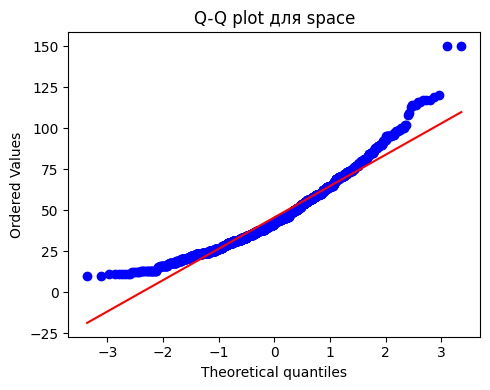

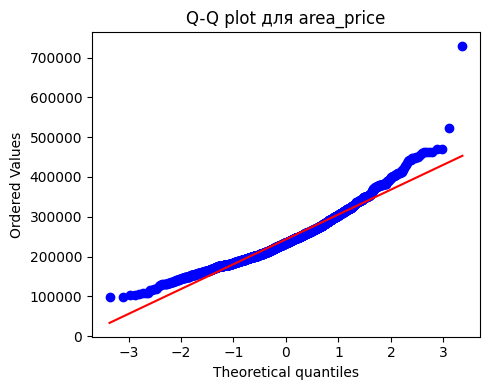

In [24]:
if space_col in df.columns and area_price_col in df.columns:
    for col in [space_col, area_price_col]:
        fig, ax = plt.subplots(figsize=(5, 4))
        stats.probplot(df[col], dist="norm", plot=ax)
        ax.set_title(f'Q-Q plot для {col}')
        plt.tight_layout()
        plt.savefig(f'qqplot_{col}.png', dpi=150)
        plt.show()

In [25]:
col = time_col
mean_val = df[col].mean()
var_val = df[col].var()
index = var_val / mean_val

print(f"Среднее (λ): {mean_val:.2f}")
print(f"Дисперсия:   {var_val:.2f}")
print(f"Индекс дисперсии: {index:.2f}")

Среднее (λ): 19.00
Дисперсия:   87.34
Индекс дисперсии: 4.60


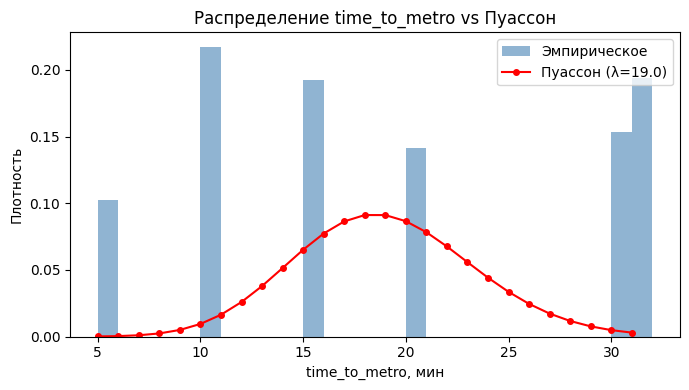

In [26]:
from scipy.stats import poisson

n = len(df)
lam = mean_val
k = np.arange(df[col].min(), df[col].max() + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[col], bins=range(df[col].min(), df[col].max() + 2),
        density=True, alpha=0.6, label='Эмпирическое', color='steelblue')
ax.plot(k, poisson.pmf(k, mu=lam), 'r-o', markersize=4, label=f'Пуассон (λ={lam:.1f})')
ax.set_xlabel('time_to_metro, мин')
ax.set_ylabel('Плотность')
ax.set_title('Распределение time_to_metro vs Пуассон')
ax.legend()
plt.tight_layout()
plt.savefig('time_to_metro_poisson.png', dpi=150)
plt.show()

μ = 12.3696, σ = 0.2544
μ = 3.7249, σ = 0.4398
μ = 16.1031, σ = 0.4490


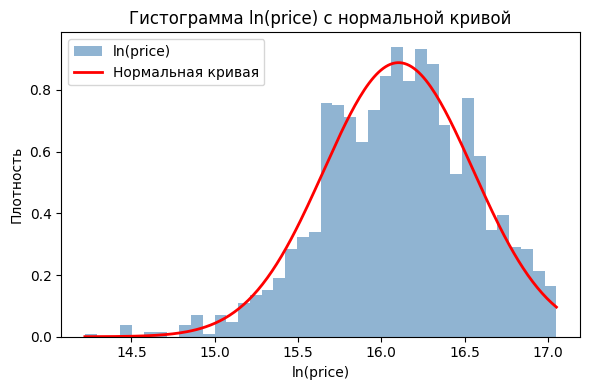

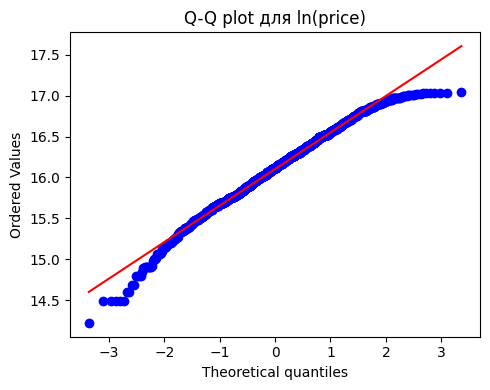

In [27]:
from scipy.stats import norm


log_price = np.log(df[area_price_col])
mu = log_price.mean()
sigma = log_price.std()
print(f"μ = {mu:.4f}, σ = {sigma:.4f}")


log_price = np.log(df[space_col])
mu = log_price.mean()
sigma = log_price.std()
print(f"μ = {mu:.4f}, σ = {sigma:.4f}")

log_price = np.log(df[price_col])
mu = log_price.mean()
sigma = log_price.std()
print(f"μ = {mu:.4f}, σ = {sigma:.4f}")

# Гистограмма
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(log_price, bins=40, density=True, alpha=0.6,
        color='steelblue', label='ln(price)')
x = np.linspace(log_price.min(), log_price.max(), 200)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='Нормальная кривая')
ax.set_xlabel('ln(price)')
ax.set_ylabel('Плотность')
ax.set_title('Гистограмма ln(price) с нормальной кривой')
ax.legend()
plt.tight_layout()
plt.savefig('log_price_hist.png', dpi=150)
plt.show()

# Q-Q plot
fig2, ax2 = plt.subplots(figsize=(5, 4))
stats.probplot(log_price, dist="norm", plot=ax2)
ax2.set_title('Q-Q plot для ln(price)')
plt.tight_layout()
plt.savefig('log_price_qqplot.png', dpi=150)
plt.show()

In [28]:
from scipy.stats import kstest, norm, lognorm, gamma

data = df[price_col].values

# Нормальное
p_norm = norm.fit(data)
ks_norm, p_norm_p = kstest(data, 'norm', args=p_norm)

# Логнормальное
p_lognorm = lognorm.fit(data, floc=0)
ks_lognorm, p_lognorm_p = kstest(data, 'lognorm', args=p_lognorm)

# Гамма
p_gamma = gamma.fit(data, floc=0)
ks_gamma, p_gamma_p = kstest(data, 'gamma', args=p_gamma)

print(f"Нормальное:    KS={ks_norm:.4f}, p={p_norm_p:.4f}")
print(f"Логнормальное: KS={ks_lognorm:.4f}, p={p_lognorm_p:.4f}")
print(f"Гамма:         KS={ks_gamma:.4f}, p={p_gamma_p:.4f}")

Нормальное:    KS=0.0805, p=0.0000
Логнормальное: KS=0.0244, p=0.2350
Гамма:         KS=0.0285, p=0.1077


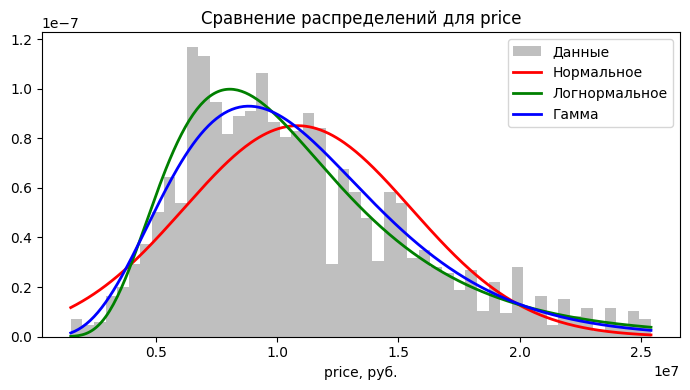

In [29]:
x = np.linspace(data.min(), data.max(), 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(data, bins=50, density=True, alpha=0.5, color='gray', label='Данные')
ax.plot(x, norm.pdf(x, *p_norm), 'r-', lw=2, label='Нормальное')
ax.plot(x, lognorm.pdf(x, *p_lognorm), 'g-', lw=2, label='Логнормальное')
ax.plot(x, gamma.pdf(x, *p_gamma), 'b-', lw=2, label='Гамма')
ax.set_xlabel('price, руб.')
ax.set_title('Сравнение распределений для price')
ax.legend()
plt.tight_layout()
plt.savefig('price_distributions.png', dpi=150)
plt.show()

In [30]:
from scipy.stats import chisquare

for col in [property_type_col, metro_col ]:
    counts = df[col].value_counts().values
    chi2, p = chisquare(counts)
    print(f"{col}: χ² = {chi2:.1f}, p-value = {p:.2e}, категорий = {len(counts)}")

type: χ² = 5023.1, p-value = 0.00e+00, категорий = 17
metro: χ² = 1326.5, p-value = 2.83e-231, категорий = 71


In [31]:
from scipy.stats import lognorm

# Используй реальные mu и sigma из np.log(df['price'])
mu = np.log(df[price_col]).mean()
sigma = np.log(df[price_col]).std()

# P(price > 15 млн)
p1 = lognorm.sf(15_000_000, s=sigma, scale=np.exp(mu))
print(f"P(price > 15 млн) = {p1:.1%}")

# 90-й перцентиль
q90 = lognorm.ppf(0.90, s=sigma, scale=np.exp(mu))
print(f"90-й перцентиль = {q90:,.0f} руб.")

# Медиана по модели
median_model = np.exp(mu)
print(f"Медиана по модели = {median_model:,.0f} руб.")

P(price > 15 млн) = 17.5%
90-й перцентиль = 17,513,719 руб.
Медиана по модели = 9,851,459 руб.


In [32]:
for col in [price_col, area_price_col]:
    if col in df.columns:
        data = df[col].dropna()
        skewness = skew(data)
        kurt = kurtosis(data)  # Fisher (excess kurtosis, нормаль = 0)
        print(f'Асимметрия {col}: {skewness:.2f}')
        print(f'Эксцесс {col}: {kurt:.2f}')

print(f'Графики сохранены в директории: {output_dir}')

Асимметрия price: 0.79
Эксцесс price: 0.25
Асимметрия area_price: 1.00
Эксцесс area_price: 2.40
Графики сохранены в директории: analysis_plots
